In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.img_converter import ImgConverter
from converters.line_heuristics.pso_search import ParticleSwarmLineSearch
from converters.tile.bin_2d import Tile2Symb2dBin
from rendering.image import render_symbols_img

from tests.experimental.test_loop import lazy_converter_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 10
GENS = 20
GENS_STEP = 5
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


In [ ]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

line_converter = ParticleSwarmLineSearch(symbols=SYMBOLS,
                                         font=FONT,
                                         generations=GENS,
                                         tile_converter=Tile2Symb2dBin(
                                             symbols=SYMBOLS, font=FONT))

converter = ImgConverter(line_converter, FONT)

line_height = int(FONT_SIZE * 1.333)
col_width = int(line_height / 2)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    col_width=col_width,
                                    line_height=line_height,
                                    gens_per_step=1000)
    results.append(res_arr)

print_gallery(results, 3)

----------------------------------------------------------------------
| ^^P" E3NlmSH1DkN4lt` | K#R%QwOZh$wQWW@@S$W# | PPRRF!:!:ueshLs9P?~` |
| qqqqqqqqqquuqu;;;;__ | ?7lj$w$Z>T?R#G7fl*F: | 2)ccL+Ll*lcL:::::::. |
| 'j/w@r?zEQ@&QQ<QWB_' | uoeZ$$Z?"' `7jeeZGZz | )4sCkZDd#W%mNaowQ%$b |
| $MQWM;uu;yQQQQ$$S$$x | 3Ze>$$$Z. ` $N&d>FpT | Jii|L""?l363IhIl:!P" |
| _{1]QQ$#aSc _ ^!tc.Z | cSK6b$$G\`  ]ZZA%qZc | }}t)J`~+:?:``'!~!:;, |
| $@@@@@@@@@@WWQQQ$$de | eeZeBm$$2 .u7'"TeeUI | \\L7!`<::.:,;uaZdBO6 |
| ^^"^^"^^""^^"^^^"''' | ''''''^^ `''`   '''' |    ```''''''''''''^' |
----------------------------------------------------------------------
-----------------------------------------------------------------
|     ` `` ````   | U;M#0wQaqtosm@g_yqtt | 4X]#_/,jWc-%CkgzJ`A  |
| `````.:``:````  | Q@QW%R##W$$ORR###MWW | N#RRRest>>[[ZF*1l?T* |
| 630@M=86vTM=u?7 | ZMQ@@Qg_nwi? P?!'^"R | wqpyL[lv5TkddZt2uua| |
| GAnM@wM0UdPdQ%8 | #RRW@W%%P`'\?'`      | d$$$##Z{' :ZZqpmbZZ( |
| nzHZH'.ZB &(Zd~ | )Hz??PP#;uP

Min: 0.0547 | Max: 0.1709 | Mean: 0.1211 | Std: 0.0319
Min: 0.0528 | Max: 0.1821 | Mean: 0.1273 | Std: 0.0381
Min: 0.0602 | Max: 0.1821 | Mean: 0.1297 | Std: 0.0372
Min: 0.0795 | Max: 0.1821 | Mean: 0.1329 | Std: 0.0345


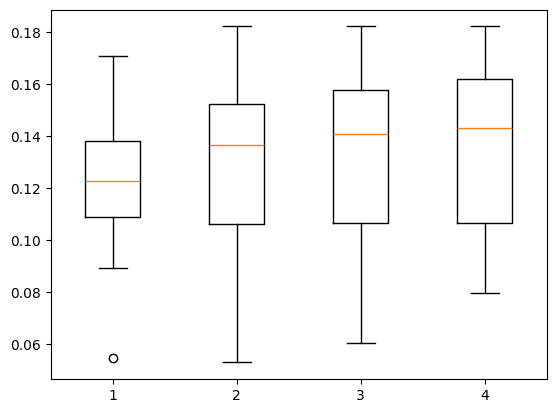

In [3]:
similarity_scores = lazy_converter_loop(IMG_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

Min: 0.0412 | Max: 0.1270 | Mean: 0.0877 | Std: 0.0223
Min: 0.0433 | Max: 0.1198 | Mean: 0.0946 | Std: 0.0228
Min: 0.0433 | Max: 0.1246 | Mean: 0.0972 | Std: 0.0237
Min: 0.0433 | Max: 0.1246 | Mean: 0.0962 | Std: 0.0240


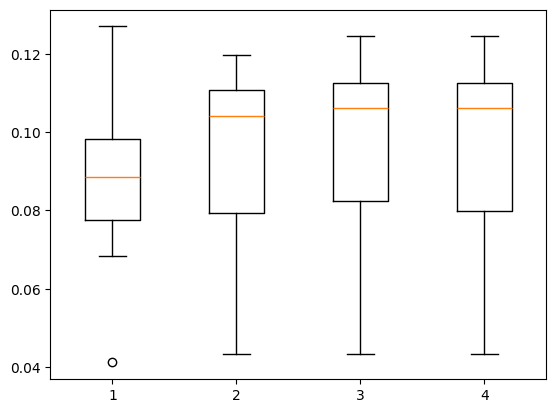

In [4]:
IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
                 for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_BIN_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

Min: 0.0152 | Max: 0.4033 | Mean: 0.1609 | Std: 0.1130
Min: 0.0334 | Max: 0.4101 | Mean: 0.1699 | Std: 0.1112
Min: 0.0334 | Max: 0.4581 | Mean: 0.1766 | Std: 0.1213
Min: 0.0285 | Max: 0.4501 | Mean: 0.1751 | Std: 0.1201


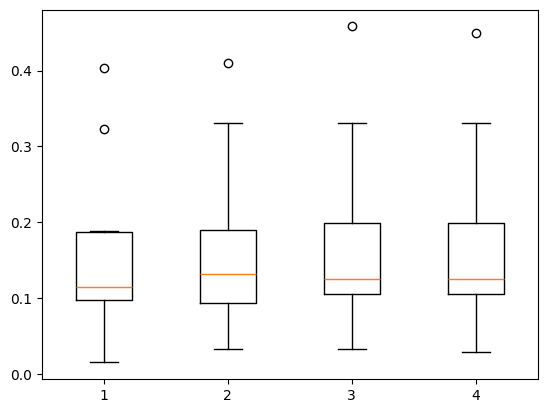

In [5]:
IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
                  for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_EDGE_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        